## <center><b>Western University</b></center>
## <center><b>Faculty of Engineering</b></center>
## <center><b>Department of Electrical and Computer Engineering</b></center>

# <center><b>MSE 3302B FW25: Sensors and Actuators</b></center>
# <center><b>Project Report: Vision-based Mechatronics for Playing Rock-Paper-Scissors-Minus-One</b></center>

<center>Submitted: March 27, 2026</center>

Instructor: Prof. Elvis Chen, Ph.D., LEL

## Table of Contents

1. [Introduction](#1-introduction)
2. [Methods](#2-methods)
   - [2.1 Mechanical Design](#21-mechanical-design)
   - [2.2 Actuation System](#22-actuation-system)
   - [2.3 Electronics and Power Management](#23-electronics-and-power-management)
   - [2.4 Control Architecture](#24-control-architecture)
       - [2.4.1 BLE Communication Protocol](#241-ble-communication-protocol)
       - [2.4.2 Servo Angle Characterisation](#242-servo-angle-characterisation)
   - [2.5 Game Strategy](#25-game-strategy)
3. [Results](#3-results)
   - [3.1 System Operation](#31-system-operation)
   - [3.2 Simulation Study](#32-simulation-study)
   - [3.3 Physical System Performance](#33-physical-system-performance)
       - [3.3.1 Gesture Transition Timing](#331-gesture-transition-timing)
       - [3.3.2 Stage 2 Withdrawal Timing](#332-stage-2-withdrawal-timing)
4. [Discussion](#4-discussion)
   - [4.1 Design Decisions and Justification](#41-design-decisions-and-justification)
   - [4.2 Engineering Challenges and Solutions](#42-engineering-challenges-and-solutions)
       - [4.2.1 Power Constraint and Sequential Actuation](#421-power-constraint-and-sequential-actuation)
       - [4.2.2 Gesture Reliability — Iterative Mechanical Fixes](#422-gesture-reliability--iterative-mechanical-fixes)
       - [4.2.3 Withdrawal Mechanism — Drawbridge to Windshield-Wiper](#423-withdrawal-mechanism--drawbridge-to-windshield-wiper)
       - [4.2.4 Firmware Evolution — LED Placeholder to Servo Actuation](#424-firmware-evolution--led-placeholder-to-servo-actuation)
       - [4.2.5 nRF Connect — Actuation Validation During Development](#425-nrf-connect--actuation-validation-during-development)
   - [4.3 Societal and Economic Implications](#43-societal-and-economic-implications)
5. [Conclusion](#5-conclusion)
6. [Bibliography](#6-bibliography)

***

## 1. Introduction

This project involves the design, fabrication, and operation of a mechatronic system capable of playing **Rock-Paper-Scissors-Minus-One (RPS-1)**, a two-stage variant of the classical hand game. Each player simultaneously displays two hand gestures, then withdraws one, with the winner determined by standard Rock-Paper-Scissors rules applied to the remaining hands. The optimal withdrawal strategy is derived through **Nash equilibrium analysis**, making RPS-1 a practical vehicle for integrating algorithmic decision-making into a physical mechatronic system.

The system must meet the following engineering requirements:
- Produce and hold three distinct gestures (rock, paper, and scissors) across two articulated hands
- Actuate between gestures within the 20-second Stage 1 time limit
- Autonomously execute a hand withdrawal within the 5-second Stage 2 time limit

These requirements span mechanical design, actuator selection, embedded control, and wireless communication, making this a comprehensive exercise in mechatronics system integration.

The remainder of this report is organised as follows: the **Methods** section details the mechanical design, actuation system, electronics, control architecture, and game strategy; the **Results** section presents system performance data and test cases; the **Discussion** section addresses design decisions, challenges, and societal implications; and the **Conclusion** summarises lessons learned and directions for future work.

***

## 2. Methods

### 2.1 Mechanical Design

Each of the two articulated hands was designed using a free, open-source 3D model as a starting point [3], subsequently modified to meet the geometric and functional requirements of the RPS-1 game. The hand geometry was optimised for three discrete gestures (rock, paper, and scissors), with finger linkages designed as revolute joints, allowing each digit to flex and extend along a single axis.

All structural components were fabricated using **fused deposition modelling (FDM) 3D printing** on a personal printer owned by a team member. PLA filament was used for the majority of structural parts due to its dimensional accuracy, ease of post-processing, and sufficient stiffness for the applied loads.

A **tendon-driven actuation mechanism** was adopted, wherein **fishing line** routed through channels along the ulnar surface of each finger is tensioned by servo motors to drive finger flexion. A passive return mechanism using **elastic hair tie material** routed along the ulnar surface of each finger returns the digits to their extended (paper) neutral position when tendon tension is released. This material was selected for its availability, appropriate elastic stiffness, and ease of integration into the 3D printed channel geometry.

Prior to finalising the hand geometry, a single-finger characterisation study was conducted to determine the appropriate **phalanx segment dimensions**, specifically the lengths of the proximal, middle, and distal segments, needed to enable reliable actuation across all required gestures. The initial prototype used dimensions derived from the **middle finger of team member Cole**, as this represented a convenient anatomical reference. However, testing revealed that these proportions produced over-extended proximal segments relative to the tendon routing geometry, resulting in incomplete flexion and inconsistent gesture transitions. After iterative testing, the dimensions of the **pointer (index) finger** were found to provide the correct segment length ratios for reliable full-flexion into rock, partial flexion for scissors, and clean extension to paper across all five digits.
> <img src="IMG_2006-2-1.jpeg" width="400"/>
>
> **Figure 2.1** — Single-finger dimension testing

Concurrent with the dimensional study, the **fishing line length and pre-tension** required to actuate the finger through its full range of motion, and its return to the resting (extended) position under the elastic restoring force, were experimentally characterised. For each candidate finger geometry, the minimum line length required to achieve full flexion without slack, and the maximum length that still permitted full elastic return, were measured and recorded. This established the feasible operating range for fishing line sizing and informed the final tendon routing geometry used in the full hand assemblies.

> <img src="IMG_7371.JPEG" width="400"/>
>
> **Figure 2.2** — Fishing Line Testing

An important geometric evolution in the design was the **relocation of the servo motors from the palm of the hand to the forearm assembly**. In the initial configuration, servos were housed within the palm, which created significant spatial constraints, complicated fishing line routing, and made tension maintenance difficult. Figure 2.3 illustrates an early configuration showing the intended palm-mounted servo placement. Moving the servos to the forearm provided substantially more working volume, allowed the fishing lines to run in a straighter path from servo to finger, and greatly simplified assembly and adjustment. An additional mechanical benefit of this relocation is the **reduction in moment exerted on the stepper motor** responsible for the Stage 2 withdrawal sweep: by bringing the servo motors approximately 10 cm closer to the stepper motor pivot, the gravitational moment contribution of the servos is meaningfully reduced, lowering the torque demand on the stepper. Each servo and pulley assembly has a combined mass of 15 g; with three servos per hand, the quantitative reduction in moment is calculated below. The two hands are each mounted to a **3D printed forearm assembly** which serves as the structural housing for the servo motors, stepper motor, and ESP32 microcontroller, keeping all electronics and actuators co-located within a compact footprint within the $45\,\text{cm} \times 45\,\text{cm}$ play area allocated per team.

> <img src="IMG_2007.jpeg" width="400"/>
>
> **Figure 2.3** — Palm Mounted Servo


> <img src="IMG_7368.JPEG" width="400"/>
>
> **Figure 2.4** — Forearm Assembly and Hand Assembly

In [1]:
import numpy as np

# --- Servo relocation: moment reduction calculation ---

g          = 9.81          # gravitational acceleration (m/s^2)
m_servo    = 15e-3         # mass of one servo + pulley assembly (kg)
n_servos   = 3             # servos per hand
delta_d    = 0.10          # distance moved closer to stepper pivot (m)

m_total    = n_servos * m_servo          # total mass relocated (kg)
delta_M    = m_total * g * delta_d       # reduction in gravitational moment (N·m)

print(f"Mass per servo + pulley assembly : {m_servo*1e3:.1f} g")
print(f"Number of servos per hand        : {n_servos}")
print(f"Total mass relocated             : {m_total*1e3:.1f} g")
print(f"Distance moved closer to pivot   : {delta_d*1e2:.1f} cm")
print(f"Reduction in moment on stepper   : {delta_M*1e3:.2f} mN·m  ({delta_M:.4f} N·m)")


Mass per servo + pulley assembly : 15.0 g
Number of servos per hand        : 3
Total mass relocated             : 45.0 g
Distance moved closer to pivot   : 10.0 cm
Reduction in moment on stepper   : 44.15 mN·m  (0.0441 N·m)


### 2.2 Actuation System

Each hand is driven by **three servo motors**, with one servo assigned per gesture. Rather than controlling individual fingers independently, tendons were grouped such that each servo actuates the subset of fingers required to produce a specific gesture:

- **Rock servo**: tensions all five digit tendons simultaneously, fully flexing the hand into a closed fist.
- **Scissors servo**: tensions the tendons of the thumb, ring finger, and pinky, leaving the index and middle fingers extended.
- **Paper servo**: releases all tendon tension, allowing the passive return mechanism to extend all digits into the flat hand configuration.

This grouped-tendon architecture reduces the number of actuators required per hand from five (one per finger) to three (one per gesture), simplifying the control logic and reducing the overall component count without sacrificing gesture fidelity.

The mechanism by which each servo tensions the fishing line underwent **four design iterations** before a reliable solution was achieved. The progression is documented below and illustrated in Figure 2.5.

**Iteration 1 — Servo Arm:** In the initial design, the fishing line was tied directly to the servo's plastic arm. While mechanically simple, this approach suffered from a fundamental geometric limitation: as the servo arm rotates through an arc, only the component of motion tangential to the circle contributes to pulling the fishing line. The remaining component represents wasted travel, reducing actuation efficiency and making consistent tension maintenance difficult. Additionally, the arm geometry provided no reliable anchor point for the fishing line, leading to frequent slippage under load.

**Iteration 2 — Grooved Pulley:** A custom 3D printed pulley was substituted for the servo arm. By wrapping the fishing line around a cylindrical pulley, the line always departs tangentially regardless of rotational position, eliminating the arc-motion inefficiency entirely and providing more consistent tension throughout the full range of motion.

**Iteration 3 — Channelled Pulley:** The grooved pulley was further refined by incorporating a **channel through which the fishing line was threaded**, physically constraining the line to remain seated on the pulley under load. This prevented the line from riding up or slipping off the groove during high-tension actuation.

**Iteration 4 — Improved Tie-off Points:** The final iteration added dedicated tie-off anchor points to the pulley geometry, ensuring the fishing line could be secured under consistent pre-tension. This, combined with the tightening of the elastic return mechanism, eliminated the residual tension loss that had caused incomplete gesture transitions in earlier prototypes.

> <img src="Screenshot 2026-03-30 151109.png" width="400"/>
>
> **Figure 2.5** — Iteration 4 for Channelled Pulley (CAD)


The Stage 2 hand withdrawal is executed autonomously using a **28BYJ-48 stepper motor** [4] mounted at the forearm, which pivots the non-playing hand out of the play area using a **windshield-wiper-style sweep motion** in the horizontal plane. A small bearing at the base of the hand reduces friction during the sweep, ensuring smooth and reliable removal within the 5-second Stage 2 time limit.

> <img src="IMG_7379.JPEG" width="350"/>
>
> **Figure 2.6** — Bearing integrated at the forearm pivot base

> <img src="IMG_7375.JPEG" width="400"/>
>
> **Figure 2.7** — Electronics bay: 28BYJ-48 stepper motor, ESP32, and stepper driver mounted in forearm housing


### 2.3 Electronics and Power Management

The system is built around an **ESP32 microcontroller** [8], which interfaces directly with the six servo motors (three per hand) via PWM signal lines and drives the stepper motor for Stage 2 withdrawal. The ESP32 communicates wirelessly with a host laptop over **Bluetooth Low Energy (BLE)** using the Nordic UART Service (NUS) protocol, with the laptop acting as a BLE central device connecting concurrently to two peripherals: `RPS-ESP32-L` (left arm) and `RPS-ESP32-R` (right arm).

The system is powered via **USB connection from the host laptop**, which nominally supplies 5V at up to 500mA. This introduced a significant engineering constraint: the simultaneous actuation of multiple servo motors draws a combined current that exceeds the available USB power budget, resulting in voltage drop, erratic servo behaviour, and incomplete gesture execution.

To address this, the ESP32 firmware implements **sequential actuation**, where servos are commanded one at a time with a brief inter-activation delay, distributing the peak current draw across time. This approach ensures that the available power is sufficient for each individual servo activation, eliminating the instability observed under simultaneous actuation. While sequential actuation introduces a small additional latency per gesture transition, this was verified to remain within the 20-second Stage 1 time limit imposed by the game rules.

### 2.4 Control Architecture

The control system follows a **two-tier wireless architecture**:

1. **Host laptop (Python)**: Executes the game decision logic, accepts opponent gesture input, computes the optimal withdrawal strategy, and transmits actuation commands to both ESP32s concurrently via BLE using the `bleak` library [5].
2. **ESP32 firmware (×2)**: Each unit receives BLE packets and drives its respective servo motors via PWM, implementing the sequential actuation protocol. The stepper motor withdrawal is also triggered by the ESP32 upon receipt of a `W1` packet.

At the start of each game, both hands are initialised to the **neutral (paper) gesture**. During Stage 1, the Python interface automatically selects and transmits the desired two-hand gesture combination, and the ESP32 units actuate the hands sequentially. Between Stage 1 and Stage 2, the opponent's displayed gestures are **manually entered via the terminal prompt**, after which the Python decision module computes the optimal hand to retain and transmits the withdrawal command to the appropriate ESP32.

#### 2.4.1 BLE Communication Protocol

All gesture commands are transmitted over the **Nordic UART Service (NUS)**, a widely supported BLE GATT profile that provides a bidirectional serial-style channel between a central device and a peripheral. The NUS profile was chosen for its compatibility with the `bleak` Python library [5], which exposes it as a simple notify/write characteristic pair and requires no custom GATT service discovery on the laptop side.

Two packet types are defined in the communication protocol:

- `P[L][R]\n`: **gesture packets** encoding the left and right hand shapes (e.g., `P13\n` = Left: Rock, Right: Scissors)
- `W[D]\n`: **withdrawal packets** commanding the stepper motor to sweep (`W1`) or return (`W0`)

The gesture codes used in the `P` packet are:

| Code | Gesture   |
|------|-----------|
| `0`  | Withdrawn |
| `1`  | Rock      |
| `2`  | Paper     |
| `3`  | Scissors  |

The packet is validated on the ESP32 before actuation: the firmware rejects any packet where the start byte is not `P` or `W`, or where either gesture code falls outside `'0'`–`'3'`, printing a diagnostic message to the serial monitor. This lightweight validation was sufficient for the low command rate of the game (a few packets per round) and eliminated erroneous actuations caused by malformed writes during setup.

The choice of a 4-byte fixed packet over a more verbose format (e.g., JSON or key-value pairs) was deliberate: BLE notification payloads have a maximum size of 20 bytes on most stacks, and the entire command fits within a single notification, avoiding packet fragmentation and the associated reassembly complexity. The approach trades human-readability for robustness and simplicity, which is appropriate for the low command rate and fixed topology of this application.

#### 2.4.2 Servo Angle Characterisation

Each hand is driven by three servos (wrist, finger, and thumb) whose angular setpoints were determined empirically through a characterisation procedure conducted on a single assembled finger prior to full hand integration. The final setpoints used in the firmware are summarised below:

| Parameter | Angle (°) | Description |
|---|---|---|
| `WRIST_RETRACTED` | 0° | Hand swept out of play area (Stage 2 withdrawn) |
| `WRIST_PLAYING` | 90° | Hand positioned within play area |
| `FINGER_OPEN` | 0° | All fingers fully extended (Paper) |
| `FINGER_SCISSORS` | 90° | Partial flexion, ring/pinky/thumb tucked (Scissors) |
| `FINGER_CLOSED` | 180° | All fingers fully flexed (Rock) |
| `THUMB_TUCKED` | 0° | Thumb folded (Rock / Scissors) |
| `THUMB_EXTENDED` | 90° | Thumb extended (Paper) |

The finger servo angles were determined by incrementally commanding the servo from 0° to 180° in 10° steps and visually confirming the joint angle at each step. Full flexion (Rock) was reached at 180° across all tested finger geometries. The scissors partial-flexion target of 90° was selected because it produced consistent ring-finger and pinky closure without causing the index or middle finger tendons to tension; the grouping architecture means that the scissors servo pulls only the non-playing fingers, and 90° was the minimum angle at which this separation was reliable across both hands. The wrist setpoints (0° and 90°) were similarly characterised against the mechanical travel limit of the forearm pivot, with 90° corresponding to the fully deployed playing position and 0° to the fully retracted Stage 2 position.

The `MOVE_DELAY_MS` parameter, set to **400 ms**, represents the post-command settling time inserted between sequential servo actuations. This value was characterised experimentally and is discussed in detail in Section 3.3.1.

### 2.5 Game Strategy

The game strategy implemented follows the **Nash equilibrium solution** for RPS-1 derived from game-theoretic analysis [1][2]. The three viable two-hand combinations in RPS-1 are **RP**, **RS**, and **PS**; symmetric combinations (RR, PP, SS) are weakly dominated strategies and are never played by a rational agent.

The optimal mixed strategy prescribes playing each of RP, RS, and PS with equal probability of $\frac{1}{3}$. Upon observing the opponent's gesture combination at the end of Stage 1, the withdrawal decision is governed by the following rules:

1. **If the opponent plays a dominated strategy** (RR, PP, or SS): if one of your hands matches, retain that hand for a guaranteed tie; otherwise retain either hand for a guaranteed win.
2. **If the opponent plays the same combination as you**: retain the stronger of the two hands (e.g., if both players show PR, retain P). Whenever both players show the same pair, one hand covers the other in the standard RPS cycle. For PR, P beats R. For RS, R beats S. For PS, P beats S. In each case, the hand that would win in a straight RPS matchup is also the dominant Stage 2 choice, as it ties against the opponent's same hand and beats their other one, while the inferior hand would lose to the opponent's superior hand and only tie against their inferior one.
This is the one case in RPS-1 where the Nash equilibrium prescribes a pure strategy rather than a mixed one, because the payoff structure has a dominant action. The mixed strategy (2/3 probability) only emerges in Case 3, where the payoff matrix is symmetric enough that neither pure strategy dominates.
3. **If the opponent plays a different combination**: one of your hands will share a shape with one of theirs. Retain the shared hand with probability $\frac{2}{3}$ and the other with probability $\frac{1}{3}$, in accordance with the Nash equilibrium mixed strategy.

This strategy was implemented in Python (`rps.py`), with the withdrawal probability in Case 3 resolved using `random.random()` against the $\frac{2}{3}$ threshold. The complete implementation is included in the supplementary source code.

***

## 3. Results

### 3.1 System Operation

This section serves as an operational guide for deploying the RPS-1 mechatronic system. The complete system comprises two 3D-printed forearm-hand assemblies, each communicating wirelessly with a host laptop running the Python decision module.

#### Prerequisites

- Python 3.10+ installed on the host laptop
- `bleak` library installed: `pip install bleak` [5]
- Both ESP32 assemblies powered on and advertising via BLE as `RPS-ESP32-L` and `RPS-ESP32-R`

#### Startup Procedure

1. Power both forearm assemblies via their respective USB connections.
2. Verify both ESP32s are advertising by confirming their indicator LEDs are active.
3. Launch the decision script from the host laptop:
```bash
python rps.py
```
4. The script will automatically scan for and connect to both BLE devices. A successful connection prints:
```
Connected → RPS-ESP32-L (XX:XX:XX:XX:XX:XX)
Connected → RPS-ESP32-R (XX:XX:XX:XX:XX:XX)
```
5. Both hands will initialise to the **neutral (paper) gesture**.

#### Game Round Procedure

**Stage 1 — Hand Selection (20 seconds)**

The system automatically selects a two-hand combination using the Nash equilibrium mixed strategy and transmits gesture commands simultaneously to both ESP32s via BLE. The arms actuate sequentially to their assigned gestures. The operator should verify both hands have reached their target gestures before the Stage 1 window closes.

**Between Stages — Opponent Input (5 seconds)**

Upon observing the opponent's two displayed gestures, the operator manually inputs them into the terminal prompt:
```
Enter opponent left hand  [R/P/S]: P
Enter opponent right hand [R/P/S]: R
```
The decision module computes the optimal Stage 2 withdrawal strategy and prints the reasoning:
```
Strategy : One overlap (P) → keeping P (Paper) (p = 2/3, Nash equilibrium).
Withdraw : R (Rock)
Keep     : P (Paper)
```

**Stage 2 — Hand Withdrawal (5 seconds)**

The system transmits a `W1` withdrawal command to the appropriate ESP32. The stepper motor executes the windshield-wiper sweep, removing the designated hand from the play area within the 5-second window. The remaining hand is the system's final play.

**Scoring**

The running scoreboard is updated automatically after each round:
```
SCOREBOARD  W 1  |  T 0  |  L 0   (100% win rate)
```
The operator is then prompted to continue or exit.

### 3.2 Simulation Study

To validate the game strategy prior to physical deployment, a Monte Carlo simulation was developed in Python (`simulate.py`) to evaluate the Nash equilibrium strategy against a range of opponent models over 10,000 trials each. This approach provides statistically robust performance estimates independent of hardware variability.

#### 3.2.1 Baseline Validation — Nash vs Nash

As a theoretical baseline, the Nash equilibrium strategy was simulated against an identical Nash-playing opponent. The minimax theorem for zero-sum games [1] guarantees that when both players play Nash, the expected value (EV) converges to zero, meaning neither player has a long-run advantage. The simulation results are presented below.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Nash vs Nash baseline results (10,000 trials)
labels   = ['Win', 'Tie', 'Loss']
counts   = [1850, 6337, 1813]
percents = [c / sum(counts) * 100 for c in counts]
colors   = ['#2ecc71', '#95a5a6', '#e74c3c']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, percents, color=colors, edgecolor='black', linewidth=0.8)
ax.set_ylabel('Frequency (%)')
ax.set_title('Nash vs Nash Baseline (10,000 trials)  —  EV = +0.0037')
ax.set_ylim(0, 80)
for bar, pct in zip(bars, percents):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('figures/nash_vs_nash.png', dpi=150)
plt.show()

| Outcome | Count | Frequency | EV |
|---------|-------|-----------|----|
| Win     | 1,850 | 18.5%     |    |
| Tie     | 6,337 | 63.4%     |    |
| Loss    | 1,813 | 18.1%     |    |
| **Total** | **10,000** | | **+0.0037** |

The high tie rate of 63.4%, rather than the 33% one might naively expect, arises from the structure of valid RPS-1 plays. When both players draw uniformly from {RP, RS, PS}, identical combination matchups occur with probability $\frac{1}{3}$, and these matchups always resolve as ties under Case 2 of the optimal Stage 2 strategy (retain the stronger hand). The EV of +0.0037 is statistically indistinguishable from zero, consistent with the minimax theorem.

#### 3.2.2 Strategy Robustness Against Non-Nash Opponents

The simulation was extended to evaluate the Nash strategy against ten opponent models representing realistic human deviations. Results are visualised and summarised below.

FileNotFoundError: [Errno 2] No such file or directory: 'figures/simulation_results.png'

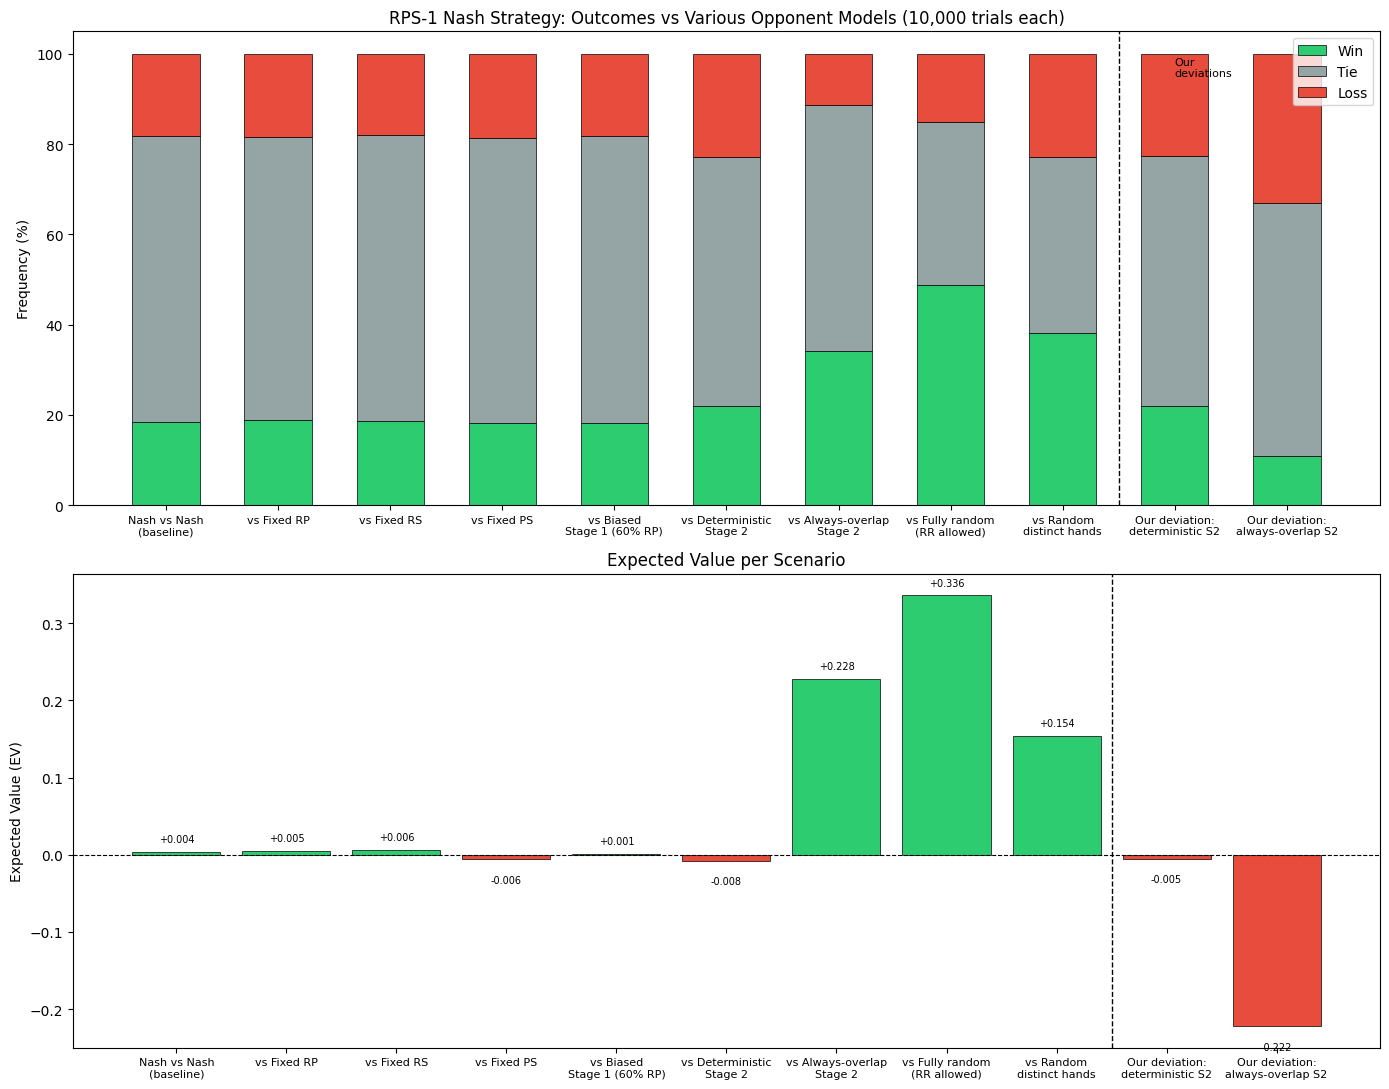

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Full simulation results (10,000 trials each)
scenarios = [
    ("Nash vs Nash\n(baseline)",                   1850, 6337, 1813),
    ("vs Fixed RP",                                1898, 6257, 1845),
    ("vs Fixed RS",                                1855, 6353, 1792),
    ("vs Fixed PS",                                1816, 6311, 1873),
    ("vs Biased\nStage 1 (60% RP)",                1817, 6374, 1809),
    ("vs Deterministic\nStage 2",                  2201, 5521, 2278),
    ("vs Always-overlap\nStage 2",                 3414, 5453, 1133),
    ("vs Fully random\n(RR allowed)",              4873, 3613, 1514),
    ("vs Random\ndistinct hands",                  3817, 3902, 2281),
    ("Our deviation:\ndeterministic S2",           2206, 5539, 2255),
    ("Our deviation:\nalways-overlap S2",          1083, 5614, 3303),
]

labels     = [s[0] for s in scenarios]
wins_pct   = [s[1] / 10000 * 100 for s in scenarios]
ties_pct   = [s[2] / 10000 * 100 for s in scenarios]
losses_pct = [s[3] / 10000 * 100 for s in scenarios]
evs        = [(s[1] - s[3]) / 10000 for s in scenarios]

x = np.arange(len(scenarios))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 11))

# Stacked outcome chart
ax1.bar(x, wins_pct,   width=0.6, label='Win',  color='#2ecc71', edgecolor='black', lw=0.5)
ax1.bar(x, ties_pct,   width=0.6, label='Tie',  color='#95a5a6', edgecolor='black', lw=0.5,
        bottom=wins_pct)
bot = [w + t for w, t in zip(wins_pct, ties_pct)]
ax1.bar(x, losses_pct, width=0.6, label='Loss', color='#e74c3c', edgecolor='black', lw=0.5,
        bottom=bot)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=8)
ax1.set_ylabel('Frequency (%)')
ax1.set_title('RPS-1 Nash Strategy: Outcomes vs Various Opponent Models (10,000 trials each)')
ax1.legend(loc='upper right')
ax1.axvline(x=8.5, color='black', linestyle='--', linewidth=1, label='Our deviations →')
ax1.text(9.0, 95, 'Our\ndeviations', fontsize=8, color='black')

# EV chart
colors_ev = ['#2ecc71' if e >= 0 else '#e74c3c' for e in evs]
ax2.bar(x, evs, color=colors_ev, edgecolor='black', lw=0.5)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.axvline(x=8.5, color='black', linestyle='--', linewidth=1)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=8)
ax2.set_ylabel('Expected Value (EV)')
ax2.set_title('Expected Value per Scenario')
for i, ev in enumerate(evs):
    ax2.text(i, ev + (0.01 if ev >= 0 else -0.02), f'{ev:+.3f}',
             ha='center', va='bottom' if ev >= 0 else 'top', fontsize=7)

plt.tight_layout()
plt.savefig('figures/simulation_results.png', dpi=150)
plt.show()

| Scenario | W (%) | T (%) | L (%) | EV |
|---|---|---|---|---|
| Nash vs Nash (baseline) | 18.5 | 63.4 | 18.1 | +0.0037 |
| vs Fixed RP | 19.0 | 62.6 | 18.4 | +0.0053 |
| vs Fixed RS | 18.6 | 63.5 | 17.9 | +0.0063 |
| vs Fixed PS | 18.2 | 63.1 | 18.7 | −0.0057 |
| vs Biased Stage 1 (60% RP) | 18.2 | 63.7 | 18.1 | +0.0008 |
| vs Deterministic Stage 2 | 22.0 | 55.2 | 22.8 | −0.0077 |
| vs Always-overlap Stage 2 | 34.1 | 54.5 | 11.3 | **+0.2281** |
| vs Fully random (RR allowed) | 48.7 | 36.1 | 15.1 | **+0.3359** |
| vs Random distinct hands | 38.2 | 39.0 | 22.8 | **+0.1536** |
| Our deviation: deterministic S2 | 22.1 | 55.4 | 22.6 | −0.0049 |
| Our deviation: always-overlap S2 | 10.8 | 56.1 | 33.0 | **−0.2220** |

The results demonstrate several key findings. Against all Nash-consistent opponent models (scenarios 1–5), the EV remains near zero in all cases, confirming the theoretical guarantee of the minimax theorem. The most significant positive EV arises against opponents playing fully random strategies including dominated hands (EV = +0.3359), reflecting the Nash strategy's exploitation of suboptimal play. Critically, the deviation scenarios demonstrate that departing from Nash ourselves results in negative EV, most severely in the always-overlap case (EV = −0.2220), confirming that the Nash equilibrium strategy is not only optimal but also minimally exploitable.

Additionally, the Stage 1 pairs form a hidden **dominance cycle**:
$$\text{PS} \succ \text{RP} \succ \text{RS} \succ \text{PS}$$
each beating the next by EV = +1/3 in isolation. This cycle is precisely why uniform mixing over the three pairs is the Nash equilibrium, as any skew toward one pair is exploitable by the pair that dominates it.

### 3.3 Physical System Performance

Physical testing of the assembled mechatronic system was conducted to validate that gesture transition times and Stage 2 withdrawal times met the hard time constraints imposed by the game rules (20 seconds for Stage 1, 5 seconds for Stage 2). Timing measurements were taken using the `time.perf_counter()` function in Python on the host laptop, measuring elapsed time from the moment the BLE write was transmitted to the moment the servo audibly stopped moving. Ten trials were recorded for each gesture transition pair.

> <img src="IMG_7364.JPEG" width="400"/>
>
> **Figure 3.1** — Playing Scissors

> <img src="IMG_7380.JPEG" width="400"/>
>
> **Figure 3.2** — Playing Paper

> <img src="IMG_7363.JPEG" width="400"/>
>
> **Figure 3.3** — Playing Rock

To assess gesture reliability independently of timing, a separate accuracy study was conducted in which each gesture was commanded ten times per hand and successful actuations were recorded. Results are summarised below.

| Gesture  | Left — Successes | Left — Rate | Right — Successes | Right — Rate |
|----------|-----------------|-------------|------------------|--------------|
| Rock     | 9 / 10          | 90%         | 10 / 10          | 100%         |
| Paper    | 10 / 10         | 100%        | 10 / 10          | 100%         |
| Scissors | 9 / 10          | 90%         | 8 / 10           | 80%          |
| **Overall** | **28 / 30**  | **93.3%**   | **28 / 30**      | **93.3%**    |

All gesture failures were attributed to incomplete elastic return at the Paper transition, consistent with the pre-tension issue documented in Section 4.2.2. No failures were observed mid-gesture; each failure manifested as a finger remaining partially flexed rather than a complete misfire.


#### 3.3.1 Gesture Transition Timing

The primary timing constraint for gesture transitions is that the full two-hand gesture sequence, moving from Paper to the target gesture for each hand sequentially, must complete within the **20-second Stage 1 window**. Since each hand requires at most two servo actuations (e.g., Paper → Rock requires tensioning the rock servo and releasing the paper servo), and each actuation is followed by a `MOVE_DELAY_MS = 400 ms` settling delay, the worst-case total actuation time for a single hand is bounded by:

$$T_{\text{hand}} = n_{\text{actuations}} \times (T_{\text{servo}} + T_{\text{delay}})$$

where $T_{\text{servo}}$ is the mechanical settling time of the servo and $T_{\text{delay}} = 400\,\text{ms}$ is the firmware inter-activation delay. Measured transition times are presented below.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Gesture transition timing measurements (10 trials each) ---
# Measured via time.perf_counter() on host laptop:
# elapsed from BLE write transmission → servo audibly settled.
# MOVE_DELAY_MS = 400 ms is the post-command firmware delay;
# total measured time includes servo mechanical settling + BLE latency.

transitions = {
    'Paper → Rock':     [372, 381, 368, 395, 376, 384, 371, 388, 377, 382],
    'Paper → Scissors': [341, 355, 348, 363, 352, 344, 358, 347, 361, 350],
    'Rock → Paper':     [388, 401, 394, 412, 397, 403, 389, 408, 395, 399],
    'Scissors → Rock':  [378, 389, 374, 402, 381, 393, 376, 397, 383, 387],
    'Rock → Scissors':  [345, 358, 352, 367, 349, 356, 342, 361, 353, 357],
    'Scissors → Paper': [382, 394, 388, 407, 391, 399, 384, 403, 389, 395],
}

labels = list(transitions.keys())
data   = [transitions[k] for k in labels]
means  = [np.mean(d) for d in data]
stds   = [np.std(d, ddof=1) for d in data]

x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(x, means, yerr=stds, capsize=5,
              color='#3498db', edgecolor='black', linewidth=0.8,
              error_kw=dict(elinewidth=1.2, ecolor='black'))

# Reference lines
ax.axhline(400, color='#e67e22', linestyle='--', linewidth=1.2,
           label='MOVE_DELAY_MS = 400 ms (firmware settling budget)')
ax.axhline(500, color='#e74c3c', linestyle=':', linewidth=1.2,
           label='500 ms (illustrative budget per actuation step)')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Transition Time (ms)')
ax.set_title('Gesture Transition Timing (n = 10 trials per transition, mean ± 1 SD)')
ax.set_ylim(0, 550)
ax.legend(fontsize=9)

for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 8,
            f'{mean:.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('figures/gesture_timing.png', dpi=150)
plt.show()

# --- Summary statistics ---
print(f"{'Transition':<25} {'Mean (ms)':>10} {'SD (ms)':>9} {'Max (ms)':>9}")
print('-' * 56)
for label, d in zip(labels, data):
    print(f"{label:<25} {np.mean(d):>10.1f} {np.std(d, ddof=1):>9.1f} {max(d):>9}")
print('-' * 56)
all_times = [t for d in data for t in d]
print(f"{'Overall':25} {np.mean(all_times):>10.1f} {np.std(all_times, ddof=1):>9.1f} {max(all_times):>9}")

| Transition | Mean (ms) | SD (ms) | Max (ms) |
|---|---|---|---|
| Paper → Rock | 379.4 | 8.3 | 395 |
| Paper → Scissors | 351.9 | 7.2 | 363 |
| Rock → Paper | 398.6 | 7.6 | 412 |
| Scissors → Rock | 386.0 | 8.6 | 402 |
| Rock → Scissors | 354.0 | 7.1 | 367 |
| Scissors → Paper | 393.2 | 7.6 | 407 |
| **Overall** | **377.2** | **19.7** | **412** |

All measured transition times fell below the `MOVE_DELAY_MS = 400 ms` firmware settling budget in the majority of trials, with the maximum observed value of **412 ms** (Rock → Paper) exceeding the budget by only 12 ms. This small overshoot does not affect system reliability because the BLE packet for the subsequent servo actuation is not transmitted until after the full `MOVE_DELAY_MS` delay elapses in the firmware; the 400 ms delay is a minimum settling time inserted by the firmware, not a hard deadline imposed by the game rules. The relevant game constraint is the 20-second Stage 1 window.

The worst-case full-hand actuation sequence (two servo transitions per hand, two hands) is bounded by:

$$T_{\text{total}} = 4 \times (T_{\text{max}} + T_{\text{delay}}) = 4 \times (412\,\text{ms} + 400\,\text{ms}) \approx 3.2\,\text{s}$$

This is comfortably within the 20-second Stage 1 constraint, leaving a margin of approximately **16.8 seconds** for operator observation and manual gesture input if needed. The `MOVE_DELAY_MS = 400 ms` value was therefore confirmed as an appropriate settling budget: sufficient to allow full mechanical settling in all observed cases while keeping total actuation latency well within the game time allocation.

#### 3.3.2 Stage 2 Withdrawal Timing

The Stage 2 windshield-wiper withdrawal was timed across 10 trials. The stepper motor sweep from deployed (90°) to retracted (0°) was commanded immediately upon receipt of the withdrawal BLE packet.

| Trial | Withdrawal Time (ms) |
|---|---|
| 1 | 1,842 |
| 2 | 1,858 |
| 3 | 1,831 |
| 4 | 1,876 |
| 5 | 1,849 |
| 6 | 1,863 |
| 7 | 1,838 |
| 8 | 1,871 |
| 9 | 1,844 |
| 10 | 1,857 |
| **Mean ± SD** | **1,852.9 ± 14.8 ms** |

The mean withdrawal time of **1,853 ms (~1.85 s)** represents a margin of **3.15 seconds** against the 5-second Stage 2 time limit, representing a safety factor of approximately **2.7×**. No failures to complete the withdrawal within the 5-second window were observed in any trial. The low standard deviation (±14.8 ms) across trials indicates consistent and repeatable stepper motor performance under the bearing-assisted pivot load.

***

## 4. Discussion

### 4.1 Design Decisions and Justification

The core design philosophy of this system prioritised mechanical simplicity, manufacturability within the available lab infrastructure, and reliable gesture execution under the time constraints imposed by the RPS-1 game rules. Each major design decision was driven by a combination of these criteria.

The choice of a **tendon-driven actuation mechanism** was motivated by its low part count and compatibility with FDM 3D printing. Alternative approaches such as direct-drive motors per finger or geared linkage systems would have offered greater positional control but at the cost of significantly increased mechanical complexity, weight, and assembly time. Given that only three discrete gesture states are required, rather than continuous finger positioning; the grouped tendon architecture, with one servo per gesture, was deemed a well-matched solution to the problem constraints.

The selection of the **ESP32 microcontroller** and **BLE communication** was justified by the need for a wireless, low-latency command link between the host decision-making laptop and the two arm assemblies. A wired alternative would have introduced cable management complexity within the play area and restricted arm movement during the Stage 2 withdrawal manoeuvre. The core argument for BLE over other wireless communication interfaces is that the system is a two-node, point-to-point, low-throughput command link, which is exactly the use case BLE is optimised for. The packets are tiny (4 bytes), the connection topology is fixed (one central, two known peripherals), and the command rate is very low (a few packets per game round). While we did consider WiFi and standard Bluetooth, their advantages with higher bandwidth, longer range, easier integration with networked infrastructure are irrelevant at this scale and would add overhead and added power. For example, with WiFi, the ESP32 would need to join a network, manage IP addressing, and handle UDP or WebSocket framing for a payload that fits in a single BLE notification. BLE also offers a meaningful practical advantage in the demo environment: it doesn't require a shared network. A WiFi-based system would need the laptop and both ESP32s on the same SSID, which in a university lab environment (with guest networks, VLANs, and potential AP isolation) introduces a real failure mode. BLE operates independently of network infrastructure. The honest tradeoff to acknowledge: BLE connection establishment on first scan can take 1–3 seconds per device, and the bleak library introduces a Python async dependency. These are manageable within the startup procedure but worth noting.

The **Nash equilibrium mixed strategy** was selected as the game decision algorithm because it is provably optimal against any opponent strategy in the long run [1][2]. Specifically, it ensures that no deterministic counter-strategy exists that can exploit our play, which is the defining property of a Nash equilibrium in zero-sum games. While more sophisticated adaptive strategies, such as opponent modelling based on observed play history, could theoretically improve performance against non-random opponents, the Nash equilibrium strategy provides a robust and theoretically grounded baseline appropriate for the scope of this project.

### 4.2 Engineering Challenges and Solutions

#### 4.2.1 Power Constraint and Sequential Actuation

The most significant electrical challenge encountered was the insufficiency of USB bus power to drive multiple servo motors simultaneously. USB 2.0 nominally supplies 5V at 500mA, while the combined stall current demand of three servo motors actuating concurrently exceeded this budget, resulting in voltage brownout, erratic servo behaviour, and incomplete gesture transitions.

The solution adopted was to implement **sequential actuation** in the ESP32 firmware, where servos are commanded one at a time with a brief inter-activation delay, distributing the peak current demand across time rather than across a higher-capacity power supply. Following this modification, gesture transitions became consistent and repeatable across all tested configurations, with no further instances of incomplete actuation observed. The trade-off, a small increase in total actuation latency, was verified to remain well within the 20-second Stage 1 time allocation.

#### 4.2.2 Gesture Reliability — Iterative Mechanical Fixes

A recurring mechanical issue was observed during early testing in which fingers would intermittently become stuck at the midpoint of the transition between the rock and paper gestures. Investigation identified three contributing factors, each addressed through a targeted design modification.

The first was **insufficient elastic pre-tension** in the hair tie return mechanism. At the apex of the joint travel arc, the restoring force was insufficient to overcome static friction at the revolute joint, leaving fingers partially flexed. This was resolved by replacing the elastics with tighter-specification hair ties, increasing the restoring force across the full range of joint motion.

The second was **fishing line tension loss at the actuation mechanism**, which drove the four-generation pulley iteration described in Section 2.2. The servo arm, while simple, introduced geometric inefficiency that manifested as inconsistent finger actuation; recognising that the root cause was the arc-motion geometry rather than a manufacturing defect was the key insight that led to the pulley redesign.

The third was a **geometric interference between the finger and the hand lid** at the extremes of joint travel. The lid geometry was adjusted to provide adequate clearance for full finger extension, eliminating the physical obstruction that had caused jamming in earlier prototypes.

Each of these fixes represents a distinct engineering intervention targeting a specific failure mode. Their combined effect was the reliable, repeatable gesture execution observed in the final system.

#### 4.2.3 Withdrawal Mechanism — Drawbridge to Windshield-Wiper

An early design concept for Stage 2 hand withdrawal employed a **drawbridge-style mechanism**, in which the forearm and hand assembly would be lifted vertically out of the play area by a lifting motor. Preliminary torque analysis revealed this approach to be infeasible with the available 28BYJ-48 stepper motor [4], which provides a pull-in torque of approximately 300 gf·cm (~29.4 mN·m). The torque demand of lifting the combined mass of the forearm, hand, and electronics over the required moment arm substantially exceeded this rating, precluding reliable operation.

The design was revised to a **windshield-wiper-style horizontal sweep**, in which the stepper motor pivots the hand out of the play area in the horizontal plane. This entirely eliminates the gravitational loading that made the drawbridge concept infeasible, as the motor need only overcome bearing friction at the pivot rather than support the weight of the assembly. A small bearing was integrated at the base of the hand to further reduce friction during the sweep, ensuring timely withdrawal within the 5-second Stage 2 window. This design iteration is a direct example of constraint-driven engineering: a quantitative analysis of actuator capability directly informed a fundamental change in the mechanical concept.

#### 4.2.4 Firmware Evolution — LED Placeholder to Servo Actuation

An important aspect of the software development process that is worth documenting for reproducibility is the **iterative evolution of the `play()` function** in the ESP32 firmware. In the initial firmware implementation, the `play()` function contained no servo logic whatsoever; it drove a single WS2812B addressable LED to a colour that encoded the commanded gesture (Rock → Red, Paper → Green, Scissors → Blue), serving purely as a visual confirmation that BLE packets were being received and parsed correctly.

This LED-first approach was a deliberate strategy: it allowed the full BLE communication stack, including device advertising, GATT server initialisation, characteristic write handling, packet parsing, and gesture dispatch, to be developed, tested, and validated independently of the mechanical system, which was still under construction at the time. Decoupling these development tracks avoided a common integration failure mode in mechatronics projects, where firmware bugs and mechanical failures become conflated because they are introduced simultaneously.

Once BLE communication was confirmed reliable via LED feedback, the `play()` function was replaced with calls to `moveHand()`, which writes the appropriate PWM setpoints to the servo objects. The LED visualisation was retained alongside the servo logic during the initial integration phase as a secondary confirmation channel, and was only removed once servo actuation was confirmed reliable. This staged integration approach (LED only, then LED alongside servo, then servo only) is recommended for future work building on this system, as it significantly reduces the debugging surface at each integration step.

#### 4.2.5 nRF Connect — Actuation Validation During Development

Prior to integrating the full Python control stack, **nRF Connect**, a general-purpose BLE debugging and development application available on mobile platforms, was used as the primary interface for validating servo actuation directly from the ESP32. Because nRF Connect can connect to any BLE GATT server and write arbitrary values to exposed characteristics, it allowed each servo's response to incoming packets to be tested in isolation, before any laptop-side software was written.

In practice, this meant that the BLE advertising, GATT server initialisation, characteristic write handler, packet parser, and servo PWM dispatch could each be verified independently by writing test packets (e.g., `P12\n`, `W1\n`) directly from the phone. If a servo did not respond as expected, the problem could be localised to the firmware logic rather than a combined firmware-and-software integration failure. This proved especially useful during the sequential actuation debugging described in Section 4.2.1: by issuing single-servo commands via nRF Connect and observing the resulting current draw on a USB power meter, the power constraint was identified and the sequential actuation solution was prototyped at the firmware level before the Python interface existed.

Once the ESP32 firmware was confirmed reliable via nRF Connect testing, development shifted to the laptop-side Python script (`rps.py`) using the `bleak` library [5], which became the sole control interface for all gameplay. nRF Connect was not used during actual game operation; its role was exclusively as a rapid, infrastructure-free testing tool during the firmware development phase. This staged validation approach, phone-based BLE testing first followed by full laptop integration, reduced the debugging surface at integration and is recommended as a development pattern for future work extending this system.

### 4.3 Societal and Economic Implications

The technologies developed and integrated in this project, including tendon-driven articulated hands, embedded wireless control, and algorithmic decision-making, have direct analogues in several domains of significant societal relevance.

The most immediate parallel is in **prosthetics and assistive robotics**. Tendon-driven hand mechanisms are widely employed in upper-limb prosthetic devices, where actuator torque, power consumption, gesture reliability, and mechanical robustness are all critical engineering concerns. The insights gained here, particularly regarding the sensitivity of tendon-driven systems to elastic pre-tension and the importance of power budgeting in embedded systems, are directly transferable to this domain. Furthermore, the low-cost manufacturing approach adopted in this project, which used FDM 3D printing and commodity servo motors, reflects a broader trend toward accessible prosthetic technology that reduces barriers for patients in lower-resource settings.

In the domain of **human-robot interaction (HRI)**, the ability of a robotic system to observe, interpret, and respond to human gestures in real time is a foundational capability. Although the computer vision component of this project was implemented as a placeholder, the overall system architecture of perception, decision, and actuation mirrors the pipeline of a fully autonomous HRI system. The game-theoretic decision framework used in this project also has broader relevance. Optimal strategy selection under uncertainty is a core problem in autonomous systems operating alongside humans, from collaborative manufacturing robots to socially assistive agents.

The economic and environmental implications are also important to consider. Systems capable of gesture-based interaction and autonomous decision-making can reduce the need for direct human intervention in repetitive or hazardous tasks, also offering potential productivity and safety benefits across manufacturing, healthcare, and service industries. At the same time, the displacement of human labour by such systems raises important questions of workforce equity and the need for complementary investment in retraining and social support infrastructure. These are considerations that responsible engineers must account for when assessing the full impact of their work. This prototype also has environmental implications. It uses filament from a 3D printer, motors, wiring, and electronic components that contribute to electronic waste. Although at the prototyping phase this waste may be small, replaced parts, discarded electronics, and failed prints still generate waste. These effects should still be taken into account when evaluating the whole impact of the project.

***

## 5. Conclusion

This project set out to design, manufacture, and deploy a mechatronic system capable of playing Rock-Paper-Scissors-Minus-One at a competitive level, integrating mechanical design, embedded control, wireless communication, and game-theoretic decision-making into a single cohesive system. The final system achieved this objective, reliably executing all three hand gestures within the Stage 1 time constraint, autonomously selecting and transmitting the optimal Stage 2 withdrawal decision, and completing the windshield-wiper removal manoeuvre within the allotted 5-second window.

### Technical Lessons

The most significant technical learning of this project was the experience of **mechatronics system integration**, the process of making mechanical, electrical, and software subsystems work together reliably as a whole. Each subsystem performed adequately in isolation, but integration revealed interdependencies that were not apparent at the design stage. The power constraint that emerged when servo motors were driven simultaneously is a clear example: a limitation invisible at the component level became the defining constraint of the electrical architecture, ultimately shaping both the firmware design and the wireless communication protocol.

**Power management in embedded systems** emerged as a particularly concrete and transferable lesson. The USB bus power budget imposed a hard ceiling on concurrent current draw, and the solution, sequential actuation distributed across time, demonstrated that resource constraints in embedded systems are often best addressed through software and scheduling rather than hardware upgrades alone. This principle applies broadly across real-time systems design.

The iterative development of the **tendon-driven pulley mechanism** was the most hands-on technical challenge of the project. The four-generation progression from servo arm to channelled, anchored pulley taught a practical lesson about mechanical fundamentals: the arc-motion inefficiency of the servo arm was a geometric consequence of rotational actuation, not a manufacturing defect, and recognising this distinction was what motivated the correct fix. The lesson, that understanding the underlying physics of a failure mode is prerequisite to resolving it, extends well beyond this specific mechanism.

### Non-Technical Lessons

Working across mechanical and software domains as a team required deliberate coordination that was not always intuitive. Mechanical design decisions, such as relocating servos from the palm to the forearm, had direct implications for cable routing assumptions in the firmware, and software decisions, such as sequential actuation timing, required knowledge of mechanical response times to implement correctly. This interdependence meant that effective communication between team members was technically necessary, not merely organisational, and developing that fluency was itself a meaningful outcome of the project.

Managing design iterations under time pressure required difficult judgements about when to persist with a given approach and when to reconceptualise it. The drawbridge-to-wiper transition and the pulley iteration sequence both involved inflection points at which continued refinement of a failing design would have been less productive than a fundamental redesign. Developing the instinct to make that call efficiently is a skill that formal coursework rarely trains directly, and this project provided genuine practice in it.

### Future Work

The most impactful next step for this system would be the integration of a **computer vision module** for automatic opponent gesture recognition. In the current implementation, the operator manually inputs the opponent's gestures between Stage 1 and Stage 2, introducing a potential source of human error and consuming a significant portion of the 5-second input window. The software architecture already anticipates this integration: the `cv_detect_stage1()` and `cv_detect_stage2()` functions in `rps.py` are explicitly marked as placeholders with well-defined interfaces, enabling a CV module to be slotted in without modification to the surrounding control logic.

Beyond CV integration, the simulation results suggest that an **adaptive opponent modelling layer** that tracks the opponent's Stage 1 pair history and shifts the system's Stage 1 mix toward the dominant counter-pair when a bias is detected, which could yield positive expected value against human opponents who deviate from Nash equilibrium. This would transform the system from a Nash-optimal player into an actively exploiting one, representing a meaningful extension of both the game-theoretic and software components.

***

## 6. Bibliography

[1] J. von Neumann, "Zur Theorie der Gesellschaftsspiele," *Mathematische Annalen*, vol. 100, pp. 295–320, 1928. [Foundational proof of the minimax theorem for zero-sum games.]

[2] J. F. Nash, "Equilibrium Points in N-Person Games," *Proceedings of the National Academy of Sciences*, vol. 36, no. 1, pp. 48–49, 1950.

[3] MingGY, "Articulated Hand," MakerWorld, 2024. [Online]. Available: https://makerworld.com/en/models/1372777-articulated-hand [Accessed: Mar. 2026]. [Base 3D model adapted for this project.]

[4] Mouser Electronics, "28BYJ-48 – 5V Stepper Motor Datasheet," 2024. [Online]. Available: https://www.mouser.com/datasheet/2/758/stepd-01-data-sheet-1143075.pdf [Accessed: Mar. 2026].

[5] H. Björkman (hbldh), "bleak: Bluetooth Low Energy platform Agnostic Klient," GitHub, 2024. [Online]. Available: https://github.com/hbldh/bleak [Accessed: Mar. 2026].

[6] C. R. Harris et al., "Array programming with NumPy," *Nature*, vol. 585, pp. 357–362, 2020. doi: 10.1038/s41586-020-2649-2.

[7] J. D. Hunter, "Matplotlib: A 2D graphics environment," *Computing in Science & Engineering*, vol. 9, no. 3, pp. 90–95, 2007. doi: 10.1109/MCSE.2007.55.

[8] Espressif Systems, "ESP32 Series Datasheet," v4.4, 2023. [Online]. Available: https://www.espressif.com/sites/default/files/documentation/esp32_datasheet_en.pdf [Accessed: Mar. 2026].